In [1]:
import os
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

cache_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'fastf1_cache')
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

Matplotlib is building the font cache; this may take a moment.


using the same session as explore.py for now

In [2]:
session = fastf1.get_session(2026, 'Hungary', 'R')
session.load()

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

In [4]:
laps = session.laps
print(laps.shape)

(1431, 31)


In [5]:
laps.dtypes

Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedelta64[ns]
Sector3SessionTime    timedelta64[ns]
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
IsPersonalBest                 object
Compound                       object
TyreLife                      float64
FreshTyre                        bool
Team                           object
LapStartTime          timedelta64[ns]
LapStartDate           datetime64[ns]
TrackStatus                    object
Position    

In [6]:
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:55:39.455000,NOR,1,0 days 00:01:31.211000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.050000,...,True,McLaren,0 days 00:54:08.019000,2026-07-26 13:03:18.361,1,2.0,False,,False,False
1,0 days 00:57:05.558000,NOR,1,0 days 00:01:26.103000,2.0,1.0,NaT,NaT,0 days 00:00:29.822000,0 days 00:00:31.728000,...,True,McLaren,0 days 00:55:39.455000,2026-07-26 13:04:49.797,1,2.0,False,,False,True
2,0 days 00:58:30.865000,NOR,1,0 days 00:01:25.307000,3.0,1.0,NaT,NaT,0 days 00:00:29.629000,0 days 00:00:31.235000,...,True,McLaren,0 days 00:57:05.558000,2026-07-26 13:06:15.900,1,2.0,False,,False,True
3,0 days 00:59:56.049000,NOR,1,0 days 00:01:25.184000,4.0,1.0,NaT,NaT,0 days 00:00:29.692000,0 days 00:00:31.177000,...,True,McLaren,0 days 00:58:30.865000,2026-07-26 13:07:41.207,1,2.0,False,,False,True
4,0 days 01:01:21.272000,NOR,1,0 days 00:01:25.223000,5.0,1.0,NaT,NaT,0 days 00:00:29.832000,0 days 00:00:30.984000,...,True,McLaren,0 days 00:59:56.049000,2026-07-26 13:09:06.391,1,2.0,False,,False,True


In [7]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [8]:
# laps per driver
laps['Driver'].value_counts()

Driver
NOR    70
RUS    70
ANT    70
LEC    70
HAD    70
VER    70
HAM    70
BOR    69
ALO    69
STR    69
HUL    69
LAW    69
GAS    69
LIN    69
SAI    68
OCO    68
COL    68
ALB    68
BEA    68
PIA    56
PER    48
BOT    14
Name: count, dtype: int64

In [11]:
# tyre compounds used across the field and how many are flagged accurate
display(laps['Compound'].value_counts())
display(laps['IsAccurate'].value_counts())

Compound
HARD      678
MEDIUM    381
SOFT      347
None       25
Name: count, dtype: int64

IsAccurate
True     1295
False     136
Name: count, dtype: int64

In [13]:
laps.isna().sum().sort_values(ascending=False)

PitOutTime            1385
PitInTime             1384
SpeedFL                 48
Sector1SessionTime      25
TyreLife                25
Sector1Time             23
Sector3SessionTime       2
LapTime                  2
SpeedST                  2
Sector3Time              2
IsPersonalBest           1
Position                 1
SpeedI1                  1
SpeedI2                  1
Sector2SessionTime       1
Sector2Time              1
DeletedReason            1
LapStartTime             0
Deleted                  0
TrackStatus              0
FastF1Generated          0
LapStartDate             0
Time                     0
Team                     0
FreshTyre                0
Compound                 0
Driver                   0
Stint                    0
LapNumber                0
DriverNumber             0
IsAccurate               0
dtype: int64

Minimal missing data for laptime


In [14]:
session.results[['Abbreviation', 'TeamName', 'GridPosition', 'Position', 'Status']]

,Abbreviation,TeamName,GridPosition,Position,Status
1,NOR,McLaren,1.0,1.0,Finished
3,VER,Red Bull Racing,4.0,2.0,Finished
12,ANT,Mercedes,7.0,3.0,Finished
16,LEC,Ferrari,2.0,4.0,Finished
44,HAM,Ferrari,5.0,5.0,Finished
6,HAD,Red Bull Racing,8.0,6.0,Finished
63,RUS,Mercedes,6.0,7.0,Finished
30,LAW,Racing Bulls,11.0,8.0,Lapped
27,HUL,Audi,10.0,9.0,Lapped
41,LIN,Racing Bulls,9.0,10.0,Lapped


## Per-driver lap time summary

Restricted to laps flagged `IsAccurate` by FastF1 (this drops in/out laps, safety car laps, and other laps FastF1 doesn't trust for pace comparisons), so the stats cover green-flag racing pace.

In [21]:
accurate_laps = laps[laps['IsAccurate']]

In [22]:
driver_stats = (
    accurate_laps.groupby('Driver')['LapTime']
    .agg(['count', 'mean', 'median', 'std', 'min'])
    .rename(columns={
        'count': 'laps', 
        'mean': 'mean_laptime',
        'median': 'median_laptime',
        'std': 'std_laptime',
        'min': 'fastest_lap',
    })
)

In [23]:
# working in seconds instead of time deltas
for col in ['mean_laptime', 'median_laptime', 'std_laptime', 'fastest_lap']:
    driver_stats[col] = driver_stats[col].dt.total_seconds()

stint_info = laps.groupby('Driver').agg(
    n_stints=('Stint', 'nunique'),
    compounds_used=('Compound', lambda s: sorted(s.dropna().unique())),
)

In [24]:
driver_stats = driver_stats.join(stint_info).sort_values('mean_laptime')
driver_stats

,laps,mean_laptime,median_laptime,std_laptime,fastest_lap,n_stints,compounds_used
Driver,,,,,,,
NOR,63,84.417683,84.4960,1.062363,82.491,4,"[HARD, MEDIUM, SOFT]"
HAM,63,84.707222,84.7430,0.916952,82.300,4,"[HARD, SOFT]"
LEC,63,84.736270,84.8760,1.113785,82.000,4,"[HARD, SOFT]"
VER,63,84.824063,85.0730,0.841246,83.433,3,"[HARD, MEDIUM, SOFT]"
ANT,63,84.872492,84.9540,1.085609,82.415,3,"[HARD, MEDIUM]"
PIA,50,85.009840,84.9150,0.649779,83.896,3,"[HARD, MEDIUM]"
RUS,64,85.327313,85.2815,1.455549,82.589,3,"[HARD, MEDIUM]"
HAD,64,85.369250,85.4650,1.189369,83.218,3,"[HARD, MEDIUM]"
LAW,62,86.260016,86.3085,0.981525,83.900,3,"[HARD, MEDIUM, SOFT]"


## Pace vs consistency

Initial very basic "similarity space", plotting mean lap time against its standard deviation. 
Drivers who are near each other here were about as fast and as consistent as each other in this race.

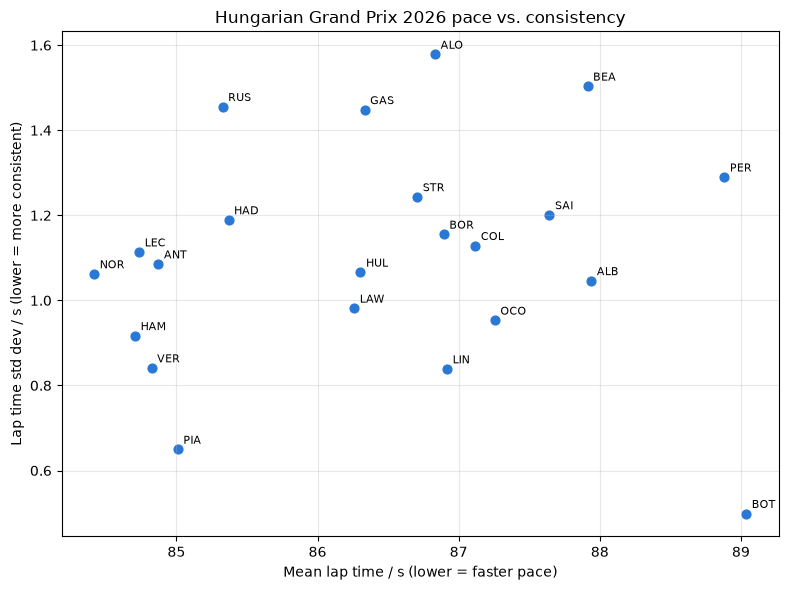

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(driver_stats['mean_laptime'], driver_stats['std_laptime'], color='#2a78d6', s=40)

for driver, row in driver_stats.iterrows():
    ax.annotate(
        driver,
        (row['mean_laptime'], row['std_laptime']),
        textcoords='offset points', xytext=(4, 4), fontsize=8
    )

ax.set_xlabel('Mean lap time / s (lower = faster pace)')
ax.set_ylabel('Lap time std dev / s (lower = more consistent)')
ax.set_title(f"{session.event['EventName']} {session.event.year} pace vs. consistency")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()